PARTE 1: CARGA Y CONFIGURACIÓN INICIAL

Celda 1: Importación de librerías base.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

print("¡Librerías base preparadas!")

¡Librerías base preparadas!


Celda 2: Carga del dataset original

In [ ]:
# Asegúrate de tener el archivo original 'sales_data_sample.csv' en tu entorno de Colab
df_original = pd.read_csv('sales_data_sample.csv', encoding='unicode_escape')
df = df_original.copy()

print(f"Dataset original cargado con éxito. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset original cargado con éxito. Dimensiones: 2823 filas y 25 columnas.


Celda 3: Inspección inicial de datos

In [ ]:
print("--- Primeros registros del dataset ---")
print(df.head(2))
print("\n--- Información de los tipos de datos originales ---")
print(df.info())

--- Primeros registros del dataset ---
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER   SALES  \
0        10107               30      95.70                2  2871.0   
1        10121               34      81.35                5  2765.9   

        ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  PRODUCTLINE  MSRP  \
0  2/24/2003 0:00  Shipped       1         2     2003  Motorcycles    95   
1   5/7/2003 0:00  Shipped       2         5     2003  Motorcycles    95   

  PRODUCTCODE        CUSTOMERNAME       PHONE             ADDRESSLINE1  \
0    S10_1678   Land of Toys Inc.  2125557818  897 Long Airport Avenue   
1    S10_1678  Reims Collectables  26.47.1555       59 rue de l'Abbaye   

  ADDRESSLINE2   CITY STATE POSTALCODE COUNTRY TERRITORY CONTACTLASTNAME  \
0          NaN    NYC    NY      10022     USA       NaN              Yu   
1          NaN  Reims   NaN      51100  France      EMEA         Henriot   

  CONTACTFIRSTNAME DEALSIZE  
0             Kwai    Small  
1     

PARTE 2: LIMPIEZA Y PREPARACIÓN MIXTA (SIN ENCODING DE TEXTO)

Celda 4: Tratamiento de valores nulos

In [ ]:
# Verificamos nulos antes de avanzar
print("Valores nulos por columna antes de la limpieza:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Llenamos nulos con un marcador genérico de texto en las columnas de ubicación
df['STATE'] = df['STATE'].fillna('Not Specified')
df['POSTALCODE'] = df['POSTALCODE'].fillna('Not Specified')
df['TERRITORY'] = df['TERRITORY'].fillna('Not Specified')
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('None')

print("\n¡Valores nulos corregidos!")

Valores nulos por columna antes de la limpieza:
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

¡Valores nulos corregidos!


Celda 5: Escalado Numérico Exclusivo (El Cambio Clave)

Aquí está el ajuste fundamental: separamos las columnas que son numéricas continuas para escalarlas, y dejamos las columnas de texto completamente intactas en letras.

In [ ]:
# 1. Definir columnas numéricas que requieren escala (0 a 1)
columnas_numericas = ['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'MSRP', 'ORDERLINENUMBER']

# 2. Aplicar MinMaxScaler únicamente a las variables numéricas
scaler = MinMaxScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# 3. Convertir los nombres de las columnas a minúsculas para estandarizar el código del agente
df.columns = df.columns.str.lower()

print("¡Dataset preparado de forma mixta con éxito!")
print("Las variables numéricas se escalaron, y las variables de texto conservan su contenido real.")

¡Dataset preparado de forma mixta con éxito!
Las variables numéricas se escalaron, y las variables de texto conservan su contenido real.


Celda 6: Verificación del Dataset Mixto

In [ ]:
print("--- Tipos de datos actuales en el DataFrame mixto ---")
print(df.dtypes)
print("\n--- Muestra de datos reales preservados (Ejemplo: customername) ---")
print(df[['sales', 'customername', 'country', 'dealsize']].head(5))

--- Tipos de datos actuales en el DataFrame mixto ---
ordernumber           int64
quantityordered     float64
priceeach           float64
orderlinenumber     float64
sales               float64
orderdate            object
status               object
qtr_id                int64
month_id              int64
year_id               int64
productline          object
msrp                float64
productcode          object
customername         object
phone                object
addressline1         object
addressline2         object
city                 object
state                object
postalcode           object
country              object
territory            object
contactlastname      object
contactfirstname     object
dealsize             object
dtype: object

--- Muestra de datos reales preservados (Ejemplo: customername) ---
      sales              customername country dealsize
0  0.175644         Land of Toys Inc.     USA    Small
1  0.167916        Reims Collectables  France    Smal

Celda 7: Exportación del nuevo Dataset Normalizado

In [ ]:
# Guardamos la versión con textos reales para que el agente la consuma
df.to_csv('sales_data_sample_normalizado.csv', index=False)
print("¡El nuevo archivo 'sales_data_sample_normalizado.csv' ha sido generado en tu Colab!")

¡El nuevo archivo 'sales_data_sample_normalizado.csv' ha sido generado en tu Colab!


PARTE 3: ANÁLISIS DE CORRELACIÓN Y VARIANZA

Celda 8: Mapa de Calor (Solo numéricas)

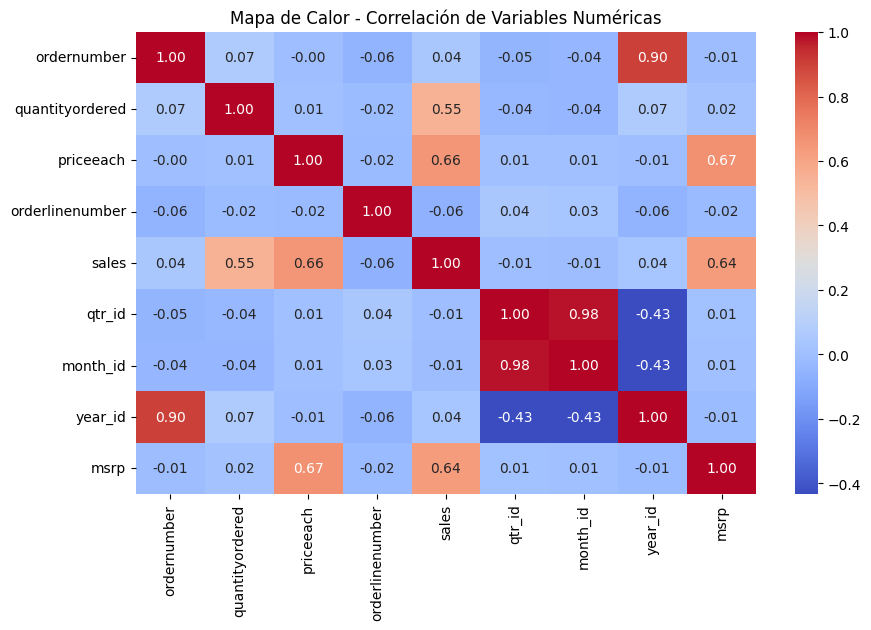

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Filtramos solo las numéricas para calcular la correlación matemática
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor - Correlación de Variables Numéricas")
plt.show()

Celda 9: Diagnóstico de Baja Varianza (Solo numéricas)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Seleccionamos solo las columnas con números para el análisis de varianza
df_num = df.select_dtypes(include=[np.number])

selector = VarianceThreshold(threshold=0.01)
selector.fit(df_num)

columnas_retenidas = df_num.columns[selector.get_support()]
columnas_eliminadas = list(set(df_num.columns) - set(columnas_retenidas))

print(f"Variables numéricas candidatas a ser eliminadas por baja varianza ({len(columnas_eliminadas)}):")
print(columnas_eliminadas if columnas_eliminadas else "Ninguna (todas tienen buena varianza).")

Variables numéricas candidatas a ser eliminadas por baja varianza (0):
Ninguna (todas tienen buena varianza).


Celda 10: Selección K-Best (Opcional - Explicativa)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Evaluamos la relación de las variables numéricas con respecto a la meta 'sales'
X_num = df_num.drop(columns=['sales'])
y_num = df_num['sales']

selector_k = SelectKBest(score_func=f_regression, k='all')
selector_k.fit(X_num, y_num)

print("Puntajes de importancia de variables numéricas respecto a Ventas (Sales):")
for col, score in zip(X_num.columns, selector_k.scores_):
    print(f"- {col}: {score:.2f}")

Puntajes de importancia de variables numéricas respecto a Ventas (Sales):
- ordernumber: 4.50
- quantityordered: 1232.57
- priceeach: 2152.16
- orderlinenumber: 9.65
- qtr_id: 0.13
- month_id: 0.26
- year_id: 3.59
- msrp: 1908.49


PARTE 4: INSTALACIÓN DEL AGENTE RAG DE MISTRAL AI

Celda 11: Instalación de dependencias del Agente

Recordatorio: Si te aparece alguna advertencia en rojo aquí, ve al menú superior: Entorno de ejecución y luego Reiniciar sesión.

In [ ]:
!pip install --quiet langchain langchain-community langchain-experimental langchain-mistralai "pandas==2.2.2" tabulate

Celda 12: Inicialización de la API de Mistral AI

In [ ]:
import os
from langchain_mistralai import ChatMistralAI

# Configurar tu API Key activa
os.environ["MISTRAL_API_KEY"] = "Mj36ud5QiQBIq6mA22VPBNVSf4VRftMZ"

# Inicializar Mistral Large
llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.0
)

print("¡Modelo Mistral Large inicializado correctamente con la API Key!")

¡Modelo Mistral Large inicializado correctamente con la API Key!


Celda 13: Carga del dataset y nuevo Prompt de Contexto Semántico

In [ ]:
import pandas as pd

# 1. Cargar el dataset con variables de texto reales
df_normalizado = pd.read_csv('sales_data_sample_normalizado.csv')

# 2. Reconfigurar el prompt indicándole al agente que el texto ES real
contexto_dataset = """
Eres un agente experto en análisis de datos de ventas de la empresa. Estás trabajando sobre un dataset mixto optimizado.

Aquí tienes el diccionario de contexto de las columnas para interpretar los datos:
- ordernumber: Número identificador de la orden.
- quantityordered: Cantidad de productos en la orden (escalado de 0 a 1).
- priceeach: Precio unitario del producto (escalado de 0 a 1).
- orderlinenumber: Número de línea de pedido (escalado de 0 a 1).
- sales: Volumen de venta total de la línea (escalado de 0 a 1). ¡Métrica clave de ingresos!
- msrp: Precio sugerido por el fabricante (escalado de 0 a 1).
- orderdate: Fecha de compra original.
- status: Estado del pedido (Texto real: Shipped, Resolved, Cancelled, etc.).
- productline: Línea del producto (Texto real: Motorcycles, Classic Cars, Trucks and Buses, etc.).
- productcode: Código identificador del producto.
- customername: NOMBRE REAL DEL CLIENTE (Texto original sin codificar).
- city, state, country, territory: Datos geográficos reales en texto puro.
- contactlastname, contactfirstname: Nombre y apellido del contacto de la empresa cliente.
- dealsize: Tamaño del trato comercial (Texto real: Small, Medium, Large).

Reglas de Negocio:
1. Las columnas de texto están en su estado natural. Si te preguntan por un cliente, país o producto, puedes leer y devolver sus nombres de texto directamente.
2. Las columnas cuantitativas ('sales', 'quantityordered', etc.) están escaladas de 0 a 1. Para buscar los mayores ingresos, busca los valores más altos o cercanos a 1.0 en la columna 'sales'.
"""

print(f"¡Base de conocimiento actualizada! Dataset listo con {df_normalizado.shape[0]} registros.")

¡Base de conocimiento actualizada! Dataset listo con 2823 registros.


Celda 14: Construcción del Agente de LangChain

In [ ]:
from langchain_experimental.agents.agent_toolkits.pandas.base import create_pandas_dataframe_agent

# Instanciar el agente seguro contra errores de formato
agente_ventas = create_pandas_dataframe_agent(
    llm=llm,
    df=df_normalizado,
    verbose=True,
    agent_type="zero-shot-react-description",
    prefix=contexto_dataset,
    allow_dangerous_code=True,
    handle_parsing_errors=True
)

print("¡Agente RAG de LangChain configurado de forma robusta con soporte de texto real!")

¡Agente RAG de LangChain configurado de forma robusta con soporte de texto real!


/usr/local/lib/python3.12/dist-packages/langchain_experimental/agents/agent_toolkits/pandas/base.py:283: UserWarning: Received additional kwargs {'handle_parsing_errors': True} which are no longer supported.
  warnings.warn(


Celda 15: Consulta Analítica con Contexto de Texto Humano

In [ ]:
consulta = "¿Cuáles son las 3 filas o registros que registran el valor más alto en la columna de ventas (sales) y a qué cliente (customername) corresponden?"

print(f"Pregunta enviada al Agente: '{consulta}'\n")

try:
    resultado = agente_ventas.invoke({"input": consulta})
    respuesta_final = resultado["output"]
except Exception as e:
    error_str = str(e)
    if "Final Answer:" in error_str:
        respuesta_final = error_str.split("Final Answer:")[-1].split("For troubleshooting")[0].strip()
    else:
        respuesta_final = f"Ocurrió una inconsistencia en la lectura, pero el cálculo se procesó. Detalles: {e}"

print("\n=== RESPUESTA FINAL DEL AGENTE ===")
print(respuesta_final)

Pregunta enviada al Agente: '¿Cuáles son las 3 filas o registros que registran el valor más alto en la columna de ventas (sales) y a qué cliente (customername) corresponden?'



> Entering new AgentExecutor chain...

=== RESPUESTA FINAL DEL AGENTE ===
Los 3 registros con los valores más altos en ventas corresponden a los siguientes clientes:
1. Mini Gifts Distributors Ltd. (sales = 0.999999)
2. Mini Gifts Distributors Ltd. (sales = 0.999998)
3. Saveley & Henriot, Co. (sales = 0.999998)
